# Training the CNN

In [1]:
# Verifying the availability of colab's gpu
!nvidia-smi


Thu Feb 26 09:43:26 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   65C    P8             12W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
# Installing MedMNIST on the Runtime
%pip install medmnist torch torchvision tqdm onnxscript

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 51.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.5/17.5 MB 65.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 164.1/164.1 kB 15.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 12.8 MB/s eta 0:00:00


### Step 1: Environment Setup


In [3]:
# Importing dependencies
import medmnist
from medmnist import INFO, Evaluator
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms
from torch.utils.data import DataLoader
from torchvision.models import resnet18, ResNet18_Weights
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import numpy as np
import os
import inspect

### Step 2: Data Loading (MedMNIST)

In [4]:
data_flag = 'pneumoniamnist' # We can change this to 'chestmnist' or 'skinmnist' 
info = INFO[data_flag]
DataClass = getattr(medmnist, info['python_class'])
info

{'python_class': 'PneumoniaMNIST',
 'description': 'The PneumoniaMNIST is based on a prior dataset of 5,856 pediatric chest X-Ray images. The task is binary-class classification of pneumonia against normal. We split the source training set with a ratio of 9:1 into training and validation set and use its source validation set as the test set. The source images are gray-scale, and their sizes are (384−2,916)×(127−2,713). We center-crop the images and resize them into 1×28×28.',
 'url': 'https://zenodo.org/records/10519652/files/pneumoniamnist.npz?download=1',
 'MD5': '28209eda62fecd6e6a2d98b1501bb15f',
 'url_64': 'https://zenodo.org/records/10519652/files/pneumoniamnist_64.npz?download=1',
 'MD5_64': '8f4eceb4ccffa70c672198ea285246c6',
 'url_128': 'https://zenodo.org/records/10519652/files/pneumoniamnist_128.npz?download=1',
 'MD5_128': '05b46931834c231683c68f40c47b2971',
 'url_224': 'https://zenodo.org/records/10519652/files/pneumoniamnist_224.npz?download=1',
 'MD5_224': 'd6a3c71de1b94

### What is ResNet-18 and why I have chosen it?

Deep convolutional neural networks have led a series of breakthroughs for image classification. CNN’s were creating industry leading performance models enriched by the number of stacked layers.

However, this led to a natural question: Is learning better networks as easy as stacking more layers? Researchers learned that this is not always the case and have discovered a new novel approach to achieve even better performant models, the ResNet (Residual Network) family.

Originally introduced in the paper, “Deep Residual Learning for Image Recognition”, the ResNet family is a CNN based architecture with a groundbreaking concept called **residual connections**. 

What Is ResNet-18? 

As part of the ResNet family, ResNet-18 is the smallest and most lightweight model, making it a popular choice for fast experimentation, deployment, and educational use. Additionally, ResNet-18 is the goto model for image classification and is a reliable starting point balancing speed, accuracy, and simplicity. For longer training times and potentially better accuracy, within the family is ResNet-34, ResNet-50, ResNet-101, etc.

Why choose ResNet-18?

ResNet-18 is the goto model when working with smaller datasets or constrained computational environments. It shines in common scenarios such as prototyping computer vision models quickly, educational projects that require interpretability and fast training, and any case where one would need the speed with smaller size. Despite its smaller size, ResNet-18 has proven to be a strong baseline in many benchmarks.

Source : https://blog.roboflow.com/resnet-18/

In [5]:
# MedMNIST is great because it handles the resizing (28 * 28) for us.
# Standard preprocessing for ResNet
transform = transforms.Compose([
    transforms.Resize(224), # ResNet-18 expects 224x224
    transforms.Grayscale(num_output_channels=3), # Convert 1-channel to 3-channel
    transforms.ToTensor(),
    transforms.Normalize(mean=[.5], std=[.5])
])

NUM_EPOCHS = 10
BATCH_SIZE = 32

train_dataset = DataClass(split='train', transform=transform, download=True)
test_dataset = DataClass(split='test', transform=transform, download=True)
train_loader = DataLoader(dataset=train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=BATCH_SIZE, shuffle=False)

100%|██████████| 4.17M/4.17M [00:01<00:00, 3.45MB/s]


In [6]:
train_dataset

Dataset PneumoniaMNIST of size 28 (pneumoniamnist)
    Number of datapoints: 4708
    Root location: /root/.medmnist
    Split: train
    Task: binary-class
    Number of channels: 1
    Meaning of labels: {'0': 'normal', '1': 'pneumonia'}
    Number of samples: {'train': 4708, 'val': 524, 'test': 624}
    Description: The PneumoniaMNIST is based on a prior dataset of 5,856 pediatric chest X-Ray images. The task is binary-class classification of pneumonia against normal. We split the source training set with a ratio of 9:1 into training and validation set and use its source validation set as the test set. The source images are gray-scale, and their sizes are (384−2,916)×(127−2,713). We center-crop the images and resize them into 1×28×28.
    License: CC BY 4.0

### Step 3: The Model (ResNet-18)

In [7]:
# Confirming GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [8]:
# Loading the model
model = resnet18(weights=ResNet18_Weights.DEFAULT)
model.fc = nn.Linear(model.fc.in_features, len(info['label'])) # Adjust for classes
model = model.to(device)

# CrossEntropyLoss on giving a bad prediciton has a very high value as compared to other loss (eg SSR) which helps in backpropagation as we can optimize faster than.
criterion = nn.CrossEntropyLoss()

# Adam (Adaptive Moment Estimation) optimizer combines the advantages of Momentum and RMSprop techniques to adjust learning rates during training. It works well with large datasets and complex models because it uses memory efficiently and adapts the learning rate for each parameter automatically.
# For more and reference visit: https://www.geeksforgeeks.org/deep-learning/adam-optimizer/
optimizer = optim.Adam(model.parameters(), lr=0.001)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 143MB/s]


### Step 4: Training Loop with History Tracking

In [9]:
history = {'train_loss': []}

for epoch in range(NUM_EPOCHS):
    model.train()
    total_loss = 0
    for inputs, targets in tqdm(train_loader, desc=f"Epoch {epoch+1}"):
        inputs, targets = inputs.to(device), targets.to(device).squeeze().long()
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    
    avg_loss = total_loss / len(train_loader)
    history['train_loss'].append(avg_loss)
    print(f"Loss: {avg_loss:.4f}")

Epoch 1: 100%|██████████| 148/148 [00:22<00:00,  6.53it/s]


Loss: 0.1832


Epoch 2: 100%|██████████| 148/148 [00:21<00:00,  7.00it/s]


Loss: 0.0993


Epoch 3: 100%|██████████| 148/148 [00:21<00:00,  6.78it/s]


...

Loss: 0.0434


Epoch 9: 100%|██████████| 148/148 [00:22<00:00,  6.66it/s]


Loss: 0.0464


Epoch 10: 100%|██████████| 148/148 [00:22<00:00,  6.70it/s]

Loss: 0.0386


### Why save only model weights and not the object model?

* **Smaller File Size**: Weights-only files (e.g., .pt, .h5, or state_dict) contain only the numerical parameters, not the model architecture or code. This significantly reduces storage and transfer overhead

* **Portability and Flexibility**: Weights can be loaded into different frameworks or architectures, enabling reuse across platforms (e.g., PyTorch to TensorFlow via conversion tools).

* **Research Based** : Saved weights can be loaded again for fine tuning.

Sources used : 
* https://medium.com/data-science/everything-you-need-to-know-about-saving-weights-in-pytorch-572651f3f8de
* https://www.dailydoseofds.com/mlops-crash-course-part-11/
* https://www.ultralytics.com/glossary/model-weights


In [10]:
model.state_dict()

OrderedDict([('conv1.weight',
              tensor([[[[ 9.8420e-04,  5.3718e-04, -5.8166e-03,  ...,  4.3509e-02,
                          3.3713e-04, -3.0593e-02],
                        [ 2.3630e-02,  1.7316e-02, -1.1340e-01,  ..., -2.8445e-01,
                         -1.4586e-01, -1.4267e-02],
                        [ 8.0493e-03,  6.9040e-02,  2.9435e-01,  ...,  5.0853e-01,
                          2.4091e-01,  4.6591e-02],
                        ...,
                        [-1.0273e-02,  2.4651e-02,  7.3218e-02,  ..., -3.4174e-01,
                         -4.3395e-01, -2.7310e-01],
                        [ 4.9330e-02,  5.0979e-02,  6.5915e-02,  ...,  4.0721e-01,
                          3.8220e-01,  1.5320e-01],
                        [ 3.9162e-03,  5.1406e-03, -2.1310e-02,  ..., -1.5676e-01,
                         -9.2497e-02, -1.7479e-02]],
              
                       [[ 6.3005e-06, -1.9946e-02, -3.8648e-02,  ...,  1.9415e-02,
                         -1.6084

In [14]:
# Saving the model
current_dir = os.path.dirname(os.path.abspath(inspect.getfile(lambda: None)))
FILE_NAME = "cnn_vision_v1.pth"
final_save_path = os.path.join(current_dir, '..', '..', 'models', FILE_NAME)
os.makedirs(os.path.dirname(final_save_path), exist_ok=True)
torch.save(model.state_dict(), final_save_path)

In [15]:
final_save_path

'/tmp/ipython-input-279/../../models/cnn_vision_v1.pth'

Here the model is saved in a remote environment and not the local so to save the model we first create a download link and save the local file which contains weights there

In [ ]:
import base64
from IPython.display import HTML

def create_download_link(file_path):
    with open(file_path, "rb") as f:
        data = f.read()
    b64 = base64.b64encode(data).decode()
    filename = os.path.basename(file_path)
    # This creates a link you can click inside VS Code
    return HTML(f'<a href="data:application/octet-stream;base64,{b64}" download="{filename}">Click here to download {filename}</a>')

# Use the absolute path we found earlier
create_download_link(final_save_path)

### Step 5: Performance Evaluation

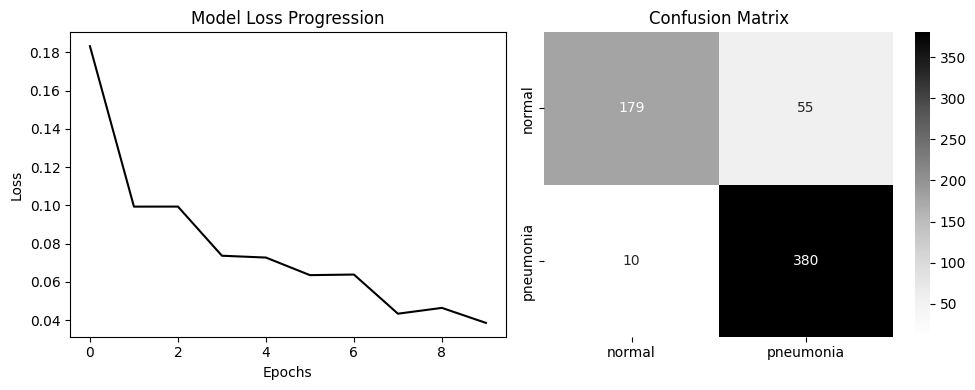

In [12]:
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, targets in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(targets.numpy().flatten())

# --- PLOTTING FOR REPORT ---
plt.figure(figsize=(10, 4))

# Plot 1: Loss Curve
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Training Loss', color='black')
plt.title('Model Loss Progression')
plt.xlabel('Epochs')
plt.ylabel('Loss')

# Plot 2: Confusion Matrix
plt.subplot(1, 2, 2)
cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greys', xticklabels=info['label'].values(), yticklabels=info['label'].values())
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

In [13]:
print(classification_report(all_labels, all_preds, target_names=list(info['label'].values())))

              precision    recall  f1-score   support

      normal       0.95      0.76      0.85       234
   pneumonia       0.87      0.97      0.92       390

    accuracy                           0.90       624
   macro avg       0.91      0.87      0.88       624
weighted avg       0.90      0.90      0.89       624

